In [1]:
!pip install nltk
!pip install textblob
!pip install pandas
!pip install scikit-learn

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ ------------------------

In [4]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd

# Load the dataset
data = pd.read_csv('Womens Clothing E-Commerce Reviews.csv')

# Display the first few rows
data.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [9]:
# Display column names and basic info
print(data.columns)
print(data.info())

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null 

In [10]:
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

def preprocess_text(text):
    if pd.isna(text):  # Handle NaN values
        return ''
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    text = text.lower()                      # Convert to lowercase
    text = ' '.join(word for word in text.split() if word not in stopwords.words('english'))
    return text

# Apply preprocessing to 'Review Text'
data['processed_text'] = data['Review Text'].apply(preprocess_text)

# Display the first few rows to check preprocessing
data[['Review Text', 'processed_text']].head()

[nltk_data] Downloading package stopwords to C:\Users\Manvi
[nltk_data]     Pandey\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,Review Text,processed_text
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...


In [13]:
from textblob import TextBlob

def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity == 0:
        return 'neutral'
    else:
        return 'negative'

# Apply sentiment analysis
data['sentiment'] = data['processed_text'].apply(get_sentiment)

# Display the results
data[['Review Text', 'processed_text', 'sentiment']].head(30)


,Review Text,processed_text,sentiment
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky sexy comfortable,positive
1,Love this dress! it's sooo pretty. i happene...,love dress sooo pretty happened find store im ...,positive
2,I had such high hopes for this dress and reall...,high hopes dress really wanted work initially ...,positive
3,"I love, love, love this jumpsuit. it's fun, fl...",love love love jumpsuit fun flirty fabulous ev...,positive
4,This shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...,positive
5,"I love tracy reese dresses, but this one is no...",love tracy reese dresses one petite feet tall ...,positive
6,I aded this in my basket at hte last mintue to...,aded basket hte last mintue see would look lik...,positive
7,"I ordered this in carbon for store pick up, an...",ordered carbon store pick ton stuff always try...,positive
8,I love this dress. i usually get an xs but it ...,love dress usually get xs runs little snug bus...,negative
9,"I'm 5""5' and 125 lbs. i ordered the s petite t...",im lbs ordered petite make sure length wasnt l...,positive


In [14]:
data.to_csv('WomenEcommerceReviewsWithSentiments.csv', index=False)

In [16]:
!pip install matplotlib

   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 209.7 kB/s eta 0:00:35
   -- ------------------------------------- 0.5/7.8 MB 209.7 kB/s eta 0:00:35
   -- ----------

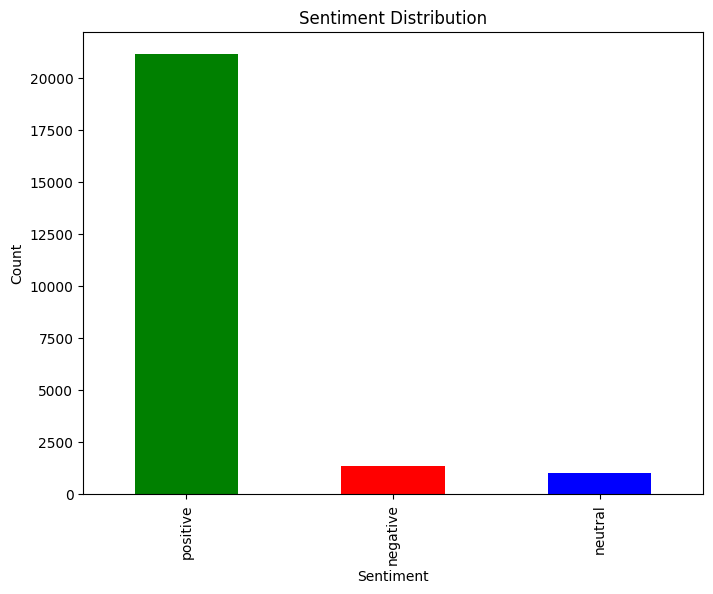

In [18]:
import matplotlib.pyplot as plt

# Count sentiment values
sentiment_counts = data['sentiment'].value_counts()

# Plot
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()